# HealthBot: AI-Powered Patient Education System

A LangGraph-based prototype built for MediTech Solutions. The bot:

1. Asks the patient for a health topic.
2. Searches Tavily for up-to-date medical information.
3. Summarizes the results in patient-friendly language.
4. Presents the summary and lets the patient read it.
5. Quizzes the patient with one comprehension question based only on the summary.
6. Grades the answer with a letter grade and a citation-backed justification.
7. Lets the patient learn about another topic (with state reset for privacy) or exit.

## 1. Setup: load environment variables

Keys are loaded from `.env` in the project folder (the assignment refers to this file as `config.env` -- here it's simply named `.env`).

In [1]:
from dotenv import load_dotenv
import os

load_dotenv(".env")

assert os.getenv("TAVILY_API_KEY") is not None, "TAVILY_API_KEY missing from .env"

# At least one LLM provider key must be present. The model selector below will
# only offer providers whose keys are actually set.
_has_openai = bool(os.getenv("OPENAI_API_KEY"))
_has_google = bool(os.getenv("GOOGLE_API_KEY"))
_has_anthropic = bool(os.getenv("ANTHROPIC_API_KEY"))
_has_openrouter = bool(os.getenv("OPENROUTER_API_KEY"))

assert any([_has_openai, _has_google, _has_anthropic, _has_openrouter]), (
    "No LLM provider API key found. Set one of OPENAI_API_KEY, GOOGLE_API_KEY, "
    "ANTHROPIC_API_KEY, or OPENROUTER_API_KEY in .env"
)

print("Tavily key loaded.")
print("OpenAI key present:", _has_openai)
print("Google key present:", _has_google)
print("Anthropic key present:", _has_anthropic)
print("OpenRouter key present:", _has_openrouter)

Tavily key loaded.
OpenAI key present: True
Google key present: True
Anthropic key present: True
OpenRouter key present: True


## 2. Imports

In [2]:
import re
import sys
import time
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

from typing import Annotated, Optional, TypedDict

from IPython.display import Markdown, display
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, RemoveMessage

## 3. Model selector

Choose which LLM provider/model drives the HealthBot for this session. Only providers with a valid key in `.env` are offered, and all of them are wrapped behind the same `BaseChatModel` interface, so every node downstream works identically regardless of which one is picked.

Your choice is the *preferred* provider rather than the only one. Every other provider with a key becomes an automatic fallback: if the preferred one hits its free-tier cap mid-session, the next one takes over instead of the session ending. See section 6.

In [3]:
# Model ids are declared once and interpolated into the menu labels below, so a
# label can never drift away from the model that actually gets instantiated.
OPENAI_MODEL = "gpt-4o-mini"
GOOGLE_MODEL = "gemini-3.5-flash-lite"
ANTHROPIC_MODEL = "claude-3-5-sonnet-latest"
OPENROUTER_MODEL = os.getenv("OPENROUTER_MODEL", "openrouter/auto")

AVAILABLE_MODELS = {}

if _has_openai:
    AVAILABLE_MODELS["1"] = {
        "label": f"OpenAI - {OPENAI_MODEL}",
        "provider": "openai",
        "model": OPENAI_MODEL,
    }
if _has_google:
    AVAILABLE_MODELS["2"] = {
        "label": f"Google Gemini - {GOOGLE_MODEL}",
        "provider": "google_genai",
        "model": GOOGLE_MODEL,
    }
if _has_anthropic:
    AVAILABLE_MODELS["3"] = {
        "label": f"Anthropic - {ANTHROPIC_MODEL}",
        "provider": "anthropic",
        "model": ANTHROPIC_MODEL,
    }
if _has_openrouter:
    AVAILABLE_MODELS["4"] = {
        "label": f"OpenRouter - {OPENROUTER_MODEL}",
        "provider": "openrouter",
        "model": OPENROUTER_MODEL,
    }


def build_chat_model(provider: str, model: str):
    """Instantiate a chat model for the given provider using the appropriate
    LangChain integration package. Returns a BaseChatModel."""
    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model=model, api_key=os.getenv("OPENAI_API_KEY"), temperature=0)
    if provider == "google_genai":
        from langchain_google_genai import ChatGoogleGenerativeAI
        return ChatGoogleGenerativeAI(model=model, api_key=os.getenv("GOOGLE_API_KEY"), temperature=0)
    if provider == "anthropic":
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(model=model, api_key=os.getenv("ANTHROPIC_API_KEY"), temperature=0)
    if provider == "openrouter":
        # OpenRouter exposes an OpenAI-compatible API, so we reuse ChatOpenAI
        # pointed at OpenRouter's base URL.
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(
            model=model,
            api_key=os.getenv("OPENROUTER_API_KEY"),
            base_url=os.getenv("OPENROUTER_ENDPOINT", "https://openrouter.ai/api/v1"),
            temperature=0,
        )
    raise ValueError(f"Unknown provider: {provider}")


def select_model() -> str:
    """Ask which provider to prefer. Returns its key in AVAILABLE_MODELS."""
    print("Select the LLM that will power this HealthBot session:")
    for key, info in AVAILABLE_MODELS.items():
        print(f"  {key}. {info['label']}")

    choice = input(f"Enter a number ({'/'.join(AVAILABLE_MODELS.keys())}): ").strip()
    while choice not in AVAILABLE_MODELS:
        choice = input("Please enter a valid option number: ").strip()

    print(f"\nPreferred: {AVAILABLE_MODELS[choice]['label']}")
    others = [AVAILABLE_MODELS[k]["label"] for k in AVAILABLE_MODELS if k != choice]
    if others:
        print("Automatic fallbacks, in order, if that provider becomes unavailable:")
        for position, label in enumerate(others, start=1):
            print(f"  {position}. {label}")
    else:
        print("No other provider keys found, so there is no fallback.")
    print()
    return choice


PREFERRED_MODEL_KEY = select_model()

Select the LLM that will power this HealthBot session:
  1. OpenAI - gpt-4o-mini
  2. Google Gemini - gemini-3.5-flash-lite
  3. Anthropic - claude-3-5-sonnet-latest
  4. OpenRouter - minimax/minimax-m3:free

Preferred: Google Gemini - gemini-3.5-flash-lite
Automatic fallbacks, in order, if that provider becomes unavailable:
  1. OpenAI - gpt-4o-mini
  2. Anthropic - claude-3-5-sonnet-latest
  3. OpenRouter - minimax/minimax-m3:free



## 4. Tavily search tool

Using the LangChain community tool for Tavily, per the project spec. `include_domains` is left open, but the search prompt instructs the model to prefer reputable medical sources (e.g. NIH, CDC, Mayo Clinic, MedlinePlus, WHO).

The tool is *not* bound to a model here. Because any of the configured providers may end up running the search, binding happens per provider inside the model pool in section 6.

In [4]:
tavily_tool = TavilySearchResults(max_results=5)

C:\Users\atuls\AppData\Local\Temp\ipykernel_29144\2436168999.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


## 5. State schema

A single `HealthBotState` TypedDict is threaded through every node. `messages` accumulates the full conversation (including tool calls/results) via LangGraph's `add_messages` reducer, so the model always has access to prior context. Topic-specific fields (`topic`, `search_results`, `summary`, `quiz_question`, `patient_answer`, `grade`, `feedback`) are explicitly cleared by the `reset_state` node whenever the patient starts a new topic, to keep information from one patient session from leaking into the next.

In [5]:
class HealthBotState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    topic: Optional[str]
    search_queries: Optional[list[str]]
    search_used_tool_call: Optional[bool]
    search_results: Optional[str]
    summary: Optional[str]
    quiz_question: Optional[str]
    patient_answer: Optional[str]
    grade: Optional[str]
    feedback: Optional[str]
    continue_session: Optional[bool]

### 5a. Model responses and conversation history

`message_text()` returns the plain text of a model response. This matters because a provider may hand back `content` as a plain string **or** as a list of content blocks (text, plus reasoning/thinking blocks and signatures). Reading `.content` directly gives you the `repr` of that list, which is how raw `[{'type': 'text', ...}]` dicts can end up in patient-facing output.

`build_model_payload()` replays the accumulated history into each request so the model has access to earlier context (the tool call, the summary, the quiz question, the patient's answer) rather than just the current instruction.

In [6]:
# ---------------------------------------------------------------------------
# Model responses
# ---------------------------------------------------------------------------
def message_text(message: AnyMessage) -> str:
    """Plain text of a model response, whatever shape the provider used.

    `content` may be a string, or a list of content blocks such as
    [{"type": "text", "text": "..."}, {"type": "thinking", ...}]. Using
    `.content` directly on the list form renders its repr -- raw dicts and
    base64 signatures -- into whatever consumes it. `.text` pulls out just the
    text blocks; the manual branch is a fallback for older langchain-core.
    """
    text = getattr(message, "text", None)
    if isinstance(text, str):
        return str(text)

    content = message.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return "".join(
            block.get("text", "")
            for block in content
            if isinstance(block, dict) and block.get("type") == "text"
        )
    return str(content)


# ---------------------------------------------------------------------------
# Conversation history
# ---------------------------------------------------------------------------
def _is_plain_text(message: AnyMessage) -> bool:
    """True for ordinary text turns -- not a tool call and not a tool result."""
    return (
        isinstance(message.content, str)
        and not isinstance(message, ToolMessage)
        and not getattr(message, "tool_calls", None)
    )


def _merge_consecutive(messages: list[AnyMessage]) -> list[AnyMessage]:
    """Collapse consecutive same-role plain-text messages into one.

    Several providers reject two messages of the same role in a row. Tool calls
    and tool results are never merged, so their pairing stays intact.
    """
    merged: list[AnyMessage] = []
    for message in messages:
        if (
            merged
            and type(merged[-1]) is type(message)
            and _is_plain_text(merged[-1])
            and _is_plain_text(message)
        ):
            merged[-1] = type(message)(content=f"{merged[-1].content}\n\n{message.content}")
        else:
            merged.append(message)
    return merged


def build_model_payload(
    system_prompt: str,
    state: HealthBotState,
    user_prompt: str,
    include_search_results: bool = True,
) -> list[AnyMessage]:
    """System prompt + accumulated message history + this turn's request.

    Pass `include_search_results=False` to drop the tool-call/tool-result pair.
    The quiz and grading nodes do that so the summary stays their only source of
    truth. Both halves of the pair are dropped together, because a tool call
    without its matching result is an invalid sequence for most providers.
    """
    history = list(state.get("messages") or [])
    if not include_search_results:
        history = [
            m for m in history
            if not isinstance(m, ToolMessage) and not getattr(m, "tool_calls", None)
        ]

    return _merge_consecutive(
        [SystemMessage(content=system_prompt), *history, HumanMessage(content=user_prompt)]
    )

### 5b. Resilient invocation with provider failover

Free-tier endpoints run out. A per-minute rate limit clears on its own, so those are retried in place with linear backoff. A *daily* cap will not clear in seconds, and neither will a bad key or a model a provider does not offer -- so rather than retrying pointlessly or ending the patient's session, `invoke_model()` moves on to the next provider that has a key in `.env`.

Once it switches, it stays switched for the rest of the session, so later nodes do not keep probing a provider that is already known to be exhausted. Every provider is tried before giving up, and only then is `HealthBotServiceError` raised, listing what each one said.

Errors that look like a bug in this notebook rather than a provider problem are raised immediately, since trying four providers would just obscure them.

In [7]:
class HealthBotServiceError(RuntimeError):
    """No configured provider could complete the request."""


class _NonRecoverable(Exception):
    """Internal marker: switching providers would not fix this error."""


# Clears on its own -> retry the same provider.
TRANSIENT_MARKERS = (
    "rate limit", "429", "overloaded", "timeout", "timed out",
    "temporarily unavailable", "502", "503", "504",
)

# Will not clear in seconds -> switch providers immediately.
DAILY_QUOTA_MARKERS = ("per day", "daily limit", "insufficient_quota", "exceeded your current quota")

# A problem with the provider or the model, not the request -> switch.
PROVIDER_MARKERS = (
    "api key", "unauthorized", "401", "403", "permission denied", "authentication",
    "not found", "404", "does not exist", "does not support", "unsupported",
    "model_not_found", "invalid model", "tool choice", "resource_exhausted", "quota",
)

MAX_ATTEMPTS = 3
BACKOFF_SECONDS = 5


def _normalize(text: str) -> str:
    """Lowercase and drop spaces/underscores, so marker matching is punctuation-agnostic."""
    return re.sub(r"[\s_]+", "", text.lower())


def _matches(error: Exception, markers: tuple[str, ...]) -> bool:
    haystack = _normalize(str(error))
    return any(_normalize(marker) in haystack for marker in markers)


def invoke_tool(tool, query, what: str = "Tavily"):
    """Invoke a search tool, retrying transient failures.

    No failover here: Tavily is the only search backend the project uses.
    """
    last_error: Exception | None = None

    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            return tool.invoke(query)
        except Exception as error:
            last_error = error
            if attempt == MAX_ATTEMPTS or not _matches(error, TRANSIENT_MARKERS):
                break
            wait = BACKOFF_SECONDS * attempt
            print(f"  ({what} hit a temporary limit -- retrying in {wait}s, attempt {attempt + 1} of {MAX_ATTEMPTS})")
            time.sleep(wait)

    raise HealthBotServiceError(
        f"Sorry -- {what} could not be completed right now. "
        f"Underlying error: {type(last_error).__name__}: {last_error}"
    ) from last_error


# Preferred provider first, then every other provider that has a key.
FAILOVER_ORDER = [PREFERRED_MODEL_KEY] + [k for k in AVAILABLE_MODELS if k != PREFERRED_MODEL_KEY]

_model_cache: dict = {}
_active_provider = 0  # index into FAILOVER_ORDER


def active_model_label() -> str:
    """Label of the provider currently serving requests, after any failover."""
    return AVAILABLE_MODELS[FAILOVER_ORDER[_active_provider]]["label"]


def _get_model(key: str, with_tools: bool):
    """Build and cache a chat model, optionally bound to the Tavily tool."""
    if (key, with_tools) in _model_cache:
        return _model_cache[(key, with_tools)]

    info = AVAILABLE_MODELS[key]
    model = build_chat_model(info["provider"], info["model"])
    if with_tools:
        # Force a tool call so the model must search rather than answer from
        # its own knowledge.
        model = model.bind_tools([tavily_tool], tool_choice="any")

    _model_cache[(key, with_tools)] = model
    return model


def _attempt(model, payload, what: str, label: str):
    """Try one provider, retrying only the failures that retrying can fix."""
    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            return model.invoke(payload)
        except Exception as error:
            if _matches(error, DAILY_QUOTA_MARKERS) or _matches(error, PROVIDER_MARKERS):
                raise  # switching providers is the fix, not waiting
            if not _matches(error, TRANSIENT_MARKERS):
                raise _NonRecoverable(str(error)) from error
            if attempt == MAX_ATTEMPTS:
                raise
            wait = BACKOFF_SECONDS * attempt
            print(f"  ({label} hit a temporary limit on {what} -- retrying in {wait}s, attempt {attempt + 1} of {MAX_ATTEMPTS})")
            time.sleep(wait)


def invoke_model(payload, what: str = "the request", with_tools: bool = False):
    """Invoke the active provider, falling back to the others if it is unavailable."""
    global _active_provider

    failures = []
    for index in range(_active_provider, len(FAILOVER_ORDER)):
        key = FAILOVER_ORDER[index]
        label = AVAILABLE_MODELS[key]["label"]

        try:
            result = _attempt(_get_model(key, with_tools), payload, what, label)
        except _NonRecoverable as error:
            # Looks like our bug, not the provider's. Surface it as-is.
            raise HealthBotServiceError(
                f"Sorry -- {what} failed for a reason that changing provider will not fix: {error}"
            ) from error.__cause__
        except Exception as error:
            failures.append(f"{label} -> {type(error).__name__}: {error}")
            remaining = FAILOVER_ORDER[index + 1:]
            if remaining:
                nxt = AVAILABLE_MODELS[remaining[0]]["label"]
                print(f"  ({label} is unavailable for {what} -- switching to {nxt} for the rest of the session)")
            continue

        # Stick with whatever worked, so later nodes skip known-dead providers.
        _active_provider = index
        return result

    raise HealthBotServiceError(
        f"Sorry -- {what} could not be completed. Every configured provider failed:\n  "
        + "\n  ".join(failures)
    )

### Patient-facing output

Everything the patient sees goes through `render_markdown()`.

Plain `print()` has two problems here. The model's emphasis, lists, and the quoted citations in its grading feedback arrive as raw `**asterisks**`, and each paragraph comes back as a single long line with no internal newlines, so nothing wraps to a sensible width and the fixed-width rulers never lined up with the body text. Rendering Markdown hands both jobs to the notebook.

The project brief suggests `print()` for patient output, so this is a deliberate deviation. Outside a notebook -- plain Python, or the logic tests -- there is no rich frontend, so `render_markdown()` falls back to lightly cleaned plain text.

In [8]:
def _in_notebook() -> bool:
    """True when running under an IPython kernel that can render rich output."""
    try:
        from IPython import get_ipython
    except ImportError:
        return False
    shell = get_ipython()
    return shell is not None and shell.__class__.__name__ == "ZMQInteractiveShell"


IN_NOTEBOOK = _in_notebook()


def _to_plain_text(markdown_text: str) -> str:
    """Strip the small subset of Markdown we emit, for non-notebook output."""
    text = re.sub(r"^#{1,6}\s*", "", markdown_text, flags=re.MULTILINE)
    text = re.sub(r"^---\s*$", "-" * 70, text, flags=re.MULTILINE)
    return text.replace("**", "")


def render_markdown(markdown_text: str) -> None:
    """Show patient-facing output, as rendered Markdown where possible."""
    # display() and input() travel over different kernel channels. Flushing
    # first keeps earlier plain-text output from landing after a prompt it was
    # meant to precede.
    sys.stdout.flush()
    if IN_NOTEBOOK:
        display(Markdown(markdown_text))
    else:
        print(_to_plain_text(markdown_text))

## 6. Nodes

Each node has a single responsibility: collecting input, calling the model, or displaying output.

In [9]:
# ---------------------------------------------------------------------------
# Node: ask_topic - collect the health topic from the patient
# ---------------------------------------------------------------------------
def ask_topic(state: HealthBotState) -> HealthBotState:
    topic = input("\nWhat health topic or medical condition would you like to learn about? ").strip()
    render_markdown(f"Got it -- let's learn about **{topic}**.")
    return {
        "topic": topic,
        "messages": [HumanMessage(content=f"I would like to learn about: {topic}")],
    }

In [10]:
# ---------------------------------------------------------------------------
# Node: search_topic - have the LLM call Tavily for the topic
#
# Hybrid approach: the LLM is required (tool_choice="any") to call the Tavily
# tool. If, for any reason, the model does not return a tool call, we fall
# back to calling Tavily directly with the topic as the query -- guaranteeing
# a search always happens.
#
# Because there are two paths, which one ran is recorded in state and shown to
# the reader. Otherwise a well-grounded summary gives no way to tell whether the
# *model* invoked the tool or HealthBot did it on the model's behalf.
# ---------------------------------------------------------------------------
SEARCH_SYSTEM_PROMPT = (
    "You are a medical research assistant. Use the tavily_search_results_json tool "
    "to search for clear, up-to-date, and reputable medical information (such as from "
    "sources like the NIH, CDC, Mayo Clinic, MedlinePlus, or WHO) about the patient's "
    "requested health topic. Formulate a focused search query for the topic."
)


def describe_search(ai_message, queries: list[str], used_tool_call: bool) -> str:
    """One line of provenance: who invoked the search tool, and with what."""
    shown = ", ".join(f"`{query}`" for query in queries)
    plural = "query" if len(queries) == 1 else "queries"

    if used_tool_call:
        tools = ", ".join(sorted({call["name"] for call in ai_message.tool_calls}))
        return (
            f"**{active_model_label()}** issued a tool call to `{tools}` "
            f"with {len(queries)} {plural}: {shown}"
        )
    return (
        f"**{active_model_label()}** returned no tool call, so HealthBot searched "
        f"Tavily directly for {shown}."
    )


def search_topic(state: HealthBotState) -> HealthBotState:
    topic = state["topic"]

    ai_message = invoke_model(
        build_model_payload(SEARCH_SYSTEM_PROMPT, state, f"Topic: {topic}"),
        what="the medical search",
        with_tools=True,
    )

    used_tool_call = bool(ai_message.tool_calls)
    queries: list[str] = []
    tool_messages = []

    if used_tool_call:
        for call in ai_message.tool_calls:
            query = call["args"].get("query", topic)
            queries.append(query)
            results = invoke_tool(tavily_tool, query)
            tool_messages.append(
                ToolMessage(content=str(results), tool_call_id=call["id"])
            )
    else:
        # Deterministic fallback: force a direct Tavily search on the topic.
        queries.append(topic)
        results = invoke_tool(tavily_tool, topic)
        tool_messages.append(ToolMessage(content=str(results), tool_call_id="fallback"))

    render_markdown(describe_search(ai_message, queries, used_tool_call))

    search_results_text = "\n\n".join(tm.content for tm in tool_messages)

    return {
        "search_results": search_results_text,
        "search_queries": queries,
        "search_used_tool_call": used_tool_call,
        "messages": [ai_message, *tool_messages],
    }

In [11]:
# ---------------------------------------------------------------------------
# Node: summarize_results - summarize Tavily results in patient-friendly language
# ---------------------------------------------------------------------------
SUMMARY_SYSTEM_PROMPT = (
    "You are HealthBot, a patient education assistant. You will be given raw search "
    "results about a health topic. Write a clear, empathetic, patient-friendly summary "
    "of 3 to 4 paragraphs.\n\n"
    "Rules:\n"
    "- Use ONLY the information contained in the provided search results. Do not add "
    "facts from your own general knowledge or any other source.\n"
    "- Avoid unexplained medical jargon; explain terms simply.\n"
    "- Do not give personalized medical advice or diagnoses -- this is general "
    "educational information only.\n"
    "- Write in plain prose paragraphs (no bullet lists, no headers)."
)


def summarize_results(state: HealthBotState) -> HealthBotState:
    prompt = (
        f"Health topic: {state['topic']}\n\n"
        f"Search results:\n{state['search_results']}\n\n"
        "Please write the 3-4 paragraph patient-friendly summary now."
    )
    # The search results are this node's source material, so the tool output
    # stays in the replayed history.
    response = invoke_model(
        build_model_payload(SUMMARY_SYSTEM_PROMPT, state, prompt),
        what="the summary",
    )
    summary = message_text(response)

    # Store the extracted text rather than the raw response, so provider-specific
    # content blocks never reach the display or the replayed history.
    return {"summary": summary, "messages": [AIMessage(content=summary)]}

In [12]:
# ---------------------------------------------------------------------------
# Node: present_summary - show the summary and let the patient read it
# ---------------------------------------------------------------------------
def present_summary(state: HealthBotState) -> HealthBotState:
    render_markdown(
        f"### Here's what we found about: {state['topic']}\n\n"
        f"{state['summary']}\n\n"
        "---"
    )
    input("Take your time reading the summary above. Press Enter when you're ready for a quick comprehension check... ")
    return {}

In [13]:
# ---------------------------------------------------------------------------
# Node: generate_quiz - create a single quiz question from the summary alone
# ---------------------------------------------------------------------------
QUIZ_SYSTEM_PROMPT = (
    "You are HealthBot, creating a single comprehension-check question for a patient. "
    "You will be given a patient-friendly summary of a health topic. Write ONE clear, "
    "specific question that tests understanding of the summary.\n\n"
    "Rules:\n"
    "- The question MUST be answerable using only the information in the summary.\n"
    "- Do not introduce facts, numbers, or terms that are not in the summary.\n"
    "- Ask an open-ended question (not multiple choice, not yes/no).\n"
    "- Output ONLY the question text, nothing else."
)


def generate_quiz(state: HealthBotState) -> HealthBotState:
    prompt = f"Summary:\n{state['summary']}\n\nWrite the single quiz question now."
    # Raw search results are excluded so the summary is the only source the
    # model can draw the question from.
    response = invoke_model(
        build_model_payload(QUIZ_SYSTEM_PROMPT, state, prompt, include_search_results=False),
        what="the quiz question",
    )
    quiz_question = message_text(response)

    return {"quiz_question": quiz_question, "messages": [AIMessage(content=quiz_question)]}

In [14]:
# ---------------------------------------------------------------------------
# Node: ask_quiz_question - present the question and collect the patient's answer
# ---------------------------------------------------------------------------
def ask_quiz_question(state: HealthBotState) -> HealthBotState:
    render_markdown(f"### Comprehension check\n\n{state['quiz_question']}")
    answer = input("Your answer: ").strip()
    return {
        "patient_answer": answer,
        "messages": [HumanMessage(content=f"My answer: {answer}")],
    }

In [15]:
# ---------------------------------------------------------------------------
# Node: grade_answer - grade the patient's answer using only the summary
# ---------------------------------------------------------------------------
GRADE_SYSTEM_PROMPT = (
    "You are HealthBot, grading a patient's answer to a comprehension-check question. "
    "You will be given the original summary, the quiz question, and the patient's answer.\n\n"
    "Rules:\n"
    "- Use ONLY the summary as your source of truth for what is correct.\n"
    "- Assign a letter grade (A, B, C, D, or F) reflecting how well the answer matches "
    "the summary's information.\n"
    "- Write a short justification (2-4 sentences) explaining the grade.\n"
    "- The justification MUST include at least one direct citation (a short quoted "
    "phrase or sentence) from the summary to reinforce the correct information.\n"
    "- Be encouraging and patient-friendly in tone, even when correcting mistakes.\n\n"
    "Respond in exactly this format:\n"
    "Grade: <letter>\n"
    "Justification: <your justification with citation(s)>"
)

# Models routinely decorate the labels the prompt asked for -- "**Grade:** B",
# "### Grade: B", "- Grade: B" -- and sometimes wrap the whole reply in a code
# fence. Matching a bare "Grade:" at line start missed all of those and silently
# reported N/A, so the labels are matched tolerantly. The leading class absorbs
# list/quote/heading/emphasis markers; the trailing \** absorbs a closing "**".
GRADE_LABEL = re.compile(r"^[ \t>*_#\-]*grade\s*[:\-]\s*\**\s*", re.IGNORECASE | re.MULTILINE)
JUSTIFICATION_LABEL = re.compile(r"^[ \t>*_#\-]*justification\s*[:\-]\s*\**\s*", re.IGNORECASE | re.MULTILINE)
LETTER_GRADE = re.compile(r"^([A-F][+-]?)(?![A-Za-z0-9])", re.IGNORECASE)


def _strip_code_fence(text: str) -> str:
    """Remove a ``` fence wrapping the whole response, if the model added one."""
    if not text.startswith("```"):
        return text
    text = re.sub(r"^```[^\n]*\n?", "", text)
    return re.sub(r"\n?```\s*$", "", text).strip()


def parse_grade_response(result_text: str) -> tuple[str, str]:
    """Split a grading response into (letter grade, justification)."""
    text = _strip_code_fence(result_text.strip())

    grade = ""
    after_grade_line = ""
    label = GRADE_LABEL.search(text)
    if label:
        newline = text.find("\n", label.end())
        end = len(text) if newline == -1 else newline
        first_line = text[label.end():end].strip()
        letter = LETTER_GRADE.match(first_line)
        # Prefer a clean letter, but keep whatever was given rather than losing it.
        grade = letter.group(1).upper() if letter else first_line
        after_grade_line = text[end:]

    justification = JUSTIFICATION_LABEL.search(text)
    if justification:
        feedback = text[justification.end():].strip()
    else:
        # No explicit label: fall back to whatever followed the grade line.
        feedback = after_grade_line.strip() or text

    return grade or "N/A", feedback


def grade_answer(state: HealthBotState) -> HealthBotState:
    prompt = (
        f"Summary:\n{state['summary']}\n\n"
        f"Quiz question: {state['quiz_question']}\n\n"
        f"Patient's answer: {state['patient_answer']}\n\n"
        "Please grade this now."
    )
    # Raw search results are excluded so the summary is the only source of truth
    # for the grade, as the project requires.
    response = invoke_model(
        build_model_payload(GRADE_SYSTEM_PROMPT, state, prompt, include_search_results=False),
        what="the grading",
    )
    result_text = message_text(response)
    grade, feedback = parse_grade_response(result_text)

    return {"grade": grade, "feedback": feedback, "messages": [AIMessage(content=result_text)]}

In [16]:
# ---------------------------------------------------------------------------
# Node: present_grade - display the grade and feedback to the patient
# ---------------------------------------------------------------------------
def present_grade(state: HealthBotState) -> HealthBotState:
    render_markdown(
        "### Your results\n\n"
        f"**Grade:** {state['grade']}\n\n"
        f"**Feedback:** {state['feedback']}"
    )
    return {}

In [17]:
# ---------------------------------------------------------------------------
# Node: ask_continue - ask whether to learn a new topic or exit
# ---------------------------------------------------------------------------
def ask_continue(state: HealthBotState) -> HealthBotState:
    choice = input("\nWould you like to learn about another health topic? (yes/no): ").strip().lower()
    return {"continue_session": choice.startswith("y")}


def route_continue(state: HealthBotState) -> str:
    return "reset_state" if state.get("continue_session") else END

In [18]:
# ---------------------------------------------------------------------------
# Node: reset_state - clear topic-specific fields before starting a new topic
#
# This protects patient privacy/accuracy: the previous topic's summary, quiz,
# answer, and grade must NOT leak into the next topic's context.
# ---------------------------------------------------------------------------
def reset_state(state: HealthBotState) -> HealthBotState:
    render_markdown("---\n\nStarting a fresh session for your new topic.")
    return {
        "messages": [RemoveMessage(id=m.id) for m in state["messages"]],
        "topic": None,
        "search_queries": None,
        "search_used_tool_call": None,
        "search_results": None,
        "summary": None,
        "quiz_question": None,
        "patient_answer": None,
        "grade": None,
        "feedback": None,
        "continue_session": None,
    }

## 7. Build the graph

The graph is cyclic: after the grade is presented, a conditional edge either loops back through `reset_state` to `ask_topic` (for a new topic, with a clean state) or ends the session.

In [19]:
graph_builder = StateGraph(HealthBotState)

graph_builder.add_node("ask_topic", ask_topic)
graph_builder.add_node("search_topic", search_topic)
graph_builder.add_node("summarize_results", summarize_results)
graph_builder.add_node("present_summary", present_summary)
graph_builder.add_node("generate_quiz", generate_quiz)
graph_builder.add_node("ask_quiz_question", ask_quiz_question)
graph_builder.add_node("grade_answer", grade_answer)
graph_builder.add_node("present_grade", present_grade)
graph_builder.add_node("ask_continue", ask_continue)
graph_builder.add_node("reset_state", reset_state)

graph_builder.add_edge(START, "ask_topic")
graph_builder.add_edge("ask_topic", "search_topic")
graph_builder.add_edge("search_topic", "summarize_results")
graph_builder.add_edge("summarize_results", "present_summary")
graph_builder.add_edge("present_summary", "generate_quiz")
graph_builder.add_edge("generate_quiz", "ask_quiz_question")
graph_builder.add_edge("ask_quiz_question", "grade_answer")
graph_builder.add_edge("grade_answer", "present_grade")
graph_builder.add_edge("present_grade", "ask_continue")
graph_builder.add_conditional_edges(
    "ask_continue",
    route_continue,
    {"reset_state": "reset_state", END: END},
)
graph_builder.add_edge("reset_state", "ask_topic")

healthbot_graph = graph_builder.compile()

### Visualize the graph (optional)

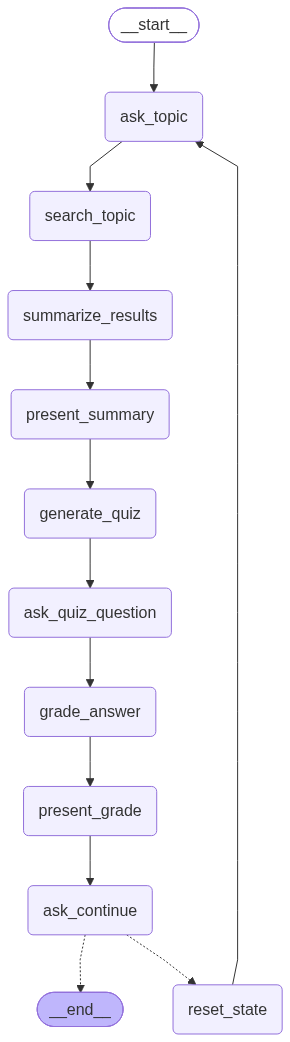

In [20]:
from IPython.display import Image, display

try:
    display(Image(healthbot_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph image (this is optional):", e)
    print(healthbot_graph.get_graph().draw_mermaid())

## 8. Run the HealthBot

Running this cell starts an interactive session. You'll be prompted (via `input()`) for a health topic, then to continue after reading the summary, then for your quiz answer, and finally whether you'd like to explore another topic.

In [21]:
initial_state: HealthBotState = {
    "messages": [],
    "topic": None,
    "search_queries": None,
    "search_used_tool_call": None,
    "search_results": None,
    "summary": None,
    "quiz_question": None,
    "patient_answer": None,
    "grade": None,
    "feedback": None,
    "continue_session": None,
}

try:
    final_state = healthbot_graph.invoke(initial_state, config={"recursion_limit": 100})
    render_markdown("**Thanks for using HealthBot. Take care!**")

    # Confirmation that the model drove the search, drawn from the final state
    # rather than from anything printed mid-run.
    if final_state.get("search_used_tool_call"):
        render_markdown(
            f"_Search provenance: the model issued the Tavily tool call itself, "
            f"querying {final_state['search_queries']}._"
        )
    else:
        render_markdown(
            "_Search provenance: the model returned no tool call, so the direct-search "
            "fallback was used._"
        )
except HealthBotServiceError as error:
    # Deliberately plain print: if the display layer itself is misbehaving, the
    # error still needs to surface.
    print(f"\n{error}")
    print("Your session stopped early. Re-run this cell to try again, or pick a different model above.")

Got it -- let's learn about **headache**.

C:\Project\HealthBot-Accen\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


**Google Gemini - gemini-3.5-flash-lite** issued a tool call to `tavily_search_results_json` with 1 query: `headache types symptoms treatments NIH CDC MedlinePlus`

C:\Project\HealthBot-Accen\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


### Here's what we found about: headache

Headaches are a common experience, with many different types categorized by their specific causes, symptoms, and treatments. The main types include tension headaches, cluster headaches, sinus headaches, migraines, medication-overuse headaches, and hormone headaches. Tension headaches are the most frequent type, affecting most adults at some point in their lives. Meanwhile, cluster headaches are rare, causing severe pain on just one side of the head that can peak quickly within minutes and last for up to a few hours, often alongside a runny or blocked nose, or a drooping or red eyelid on one side of the face.

Migraines are a more severe type of vascular headache that involve throbbing pain on one or both sides of the head. Alongside head pain, individuals experiencing a migraine may suffer from nausea, vomiting, sensitivity to light and sound, or disturbing vision changes. Prior to a migraine, some people experience a warning sign called an aura—a group of nervous system symptoms that frequently affect vision, though they can also include dizziness, trouble finding words, difficulty concentrating, or numbness and tingling. Lingering symptoms, sometimes called a migraine hangover, can also persist after the headache itself has gone away.

For many standard headaches, pain relief can often be achieved using simple over-the-counter pain medications like paracetamol, ibuprofen, or aspirin, while tension headaches can often be prevented through simple lifestyle changes to avoid known triggers. Healthcare providers can diagnose conditions like migraines by evaluating symptoms, family history, and performing complete physical and neurological exams to rule out muscle tension, sinus issues, or other brain disorders. 

While most headaches are not emergencies, it is critical to get medical attention right away if a headache occurs suddenly and feels explosive. A sudden, explosive headache can be a sign of a serious condition like a brain aneurysm, which happens when an artery in the brain fills with blood and can be fatal if it bursts.

---

...

### Comprehension check

What are the most effective and practical approaches to help prevent catching or spreading a cold?

C:\Project\HealthBot-Accen\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


### Your results

**Grade:** B

**Feedback:** You correctly identified one of the helpful prevention steps by mentioning staying away from sick individuals. However, the summary notes that the single most effective and practical approach is "practicing good hand hygiene," such as washing your hands regularly or using hand sanitizer. Great job thinking about how to avoid illness, and keep up the wonderful effort!

**Thanks for using HealthBot. Take care!**

_Search provenance: the model issued the Tavily tool call itself, querying ['common cold CDC overview symptoms treatment prevention']._